# Lab 08 - Capstone Student Performance

## Data Story

We are helping an education team understand and predict student performance.

Business question:

**Which study-related factors are most connected to performance, and can we predict performance?**

In [1]:
pip install pandas numpy matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 50)

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

In [14]:
df = pd.read_csv("dataset/Student_Performance.csv")
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


## 1. Understand the Dataset

In [5]:
print("Rows and columns:", df.shape)
display(df.info())
display(df.describe(include="all").T)
display(df.isnull().sum().to_frame("Missing Values"))

Rows and columns: (10000, 6)
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  str    
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), str(1)
memory usage: 468.9 KB


None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Hours Studied,10000.0,NaN,NaN,NaN,4.9929,2.589309,1.0,3.0,5.0,7.0,9.0
Previous Scores,10000.0,NaN,NaN,NaN,69.4457,17.343152,40.0,54.0,69.0,85.0,99.0
Extracurricular Activities,10000,2,No,5052,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sleep Hours,10000.0,NaN,NaN,NaN,6.5306,1.695863,4.0,5.0,7.0,8.0,9.0
Sample Question Papers Practiced,10000.0,NaN,NaN,NaN,4.5833,2.867348,0.0,2.0,5.0,7.0,9.0
Performance Index,10000.0,NaN,NaN,NaN,55.2248,19.212558,10.0,40.0,55.0,71.0,100.0


,Missing Values
Hours Studied,0
Previous Scores,0
Extracurricular Activities,0
Sleep Hours,0
Sample Question Papers Practiced,0
Performance Index,0


## 2. Visual Story

Study hours and previous scores are likely important. Let us inspect them.

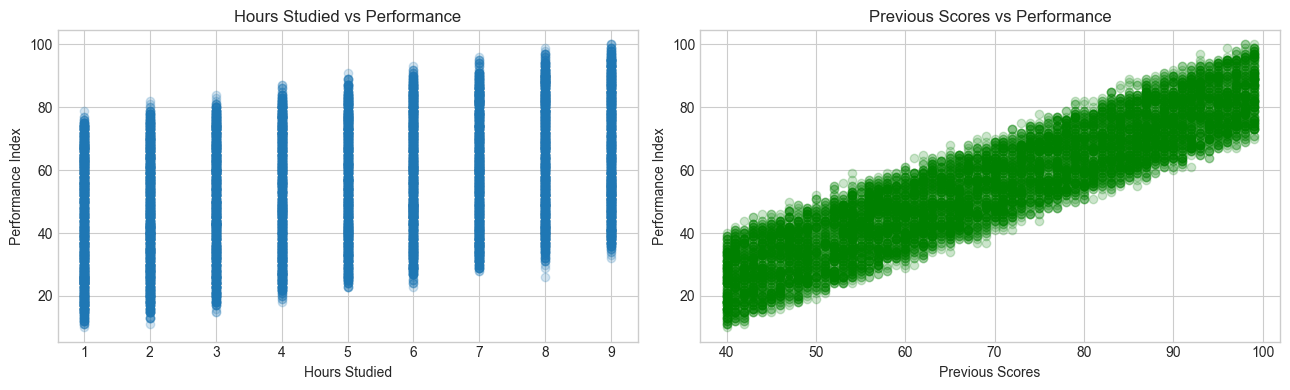

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].scatter(df["Hours Studied"], df["Performance Index"], alpha=0.2)
axes[0].set_title("Hours Studied vs Performance")
axes[0].set_xlabel("Hours Studied")
axes[0].set_ylabel("Performance Index")

axes[1].scatter(df["Previous Scores"], df["Performance Index"], alpha=0.2, color="green")
axes[1].set_title("Previous Scores vs Performance")
axes[1].set_xlabel("Previous Scores")
axes[1].set_ylabel("Performance Index")

plt.tight_layout()
plt.show()

## 3. Evidence: Correlation

Previous Scores                     0.915189
Hours Studied                       0.373730
Sleep Hours                         0.048106
Sample Question Papers Practiced    0.043268
Name: Performance Index, dtype: float64

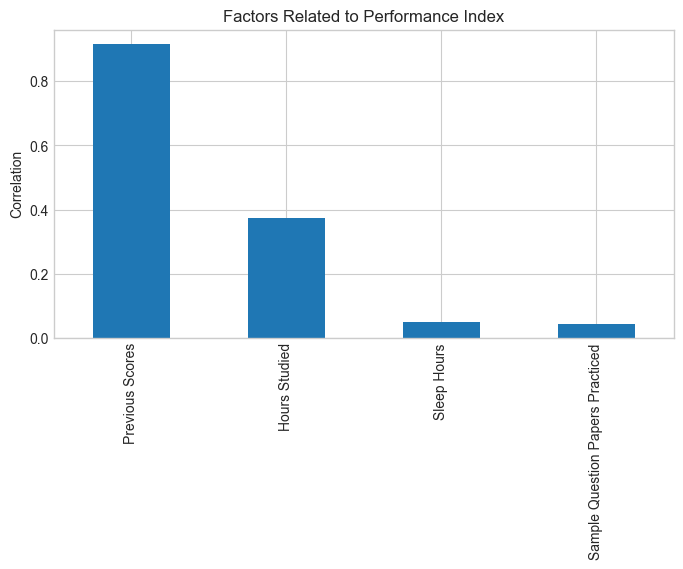

In [7]:
numeric_df = df.select_dtypes(include=np.number)
correlations = numeric_df.corr()["Performance Index"].drop("Performance Index").sort_values(ascending=False)
display(correlations)

correlations.plot(kind="bar", figsize=(8, 4))
plt.title("Factors Related to Performance Index")
plt.ylabel("Correlation")
plt.show()

## 4. Build the Prediction Model

In [8]:
target_column = "Performance Index"

X = df.drop(columns=[target_column])
y = df[target_column]

X_encoded = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

predictions = model.predict(X_test)

mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("Mean Absolute Error:", round(mae, 2))
print("R2 Score:", round(r2, 3))

Mean Absolute Error: 1.61
R2 Score: 0.989


## 5. Explain Predictions

In [9]:
results = pd.DataFrame({
    "Actual Performance": y_test.values,
    "Predicted Performance": predictions,
    "Error": y_test.values - predictions
})

results.head(10)

,Actual Performance,Predicted Performance,Error
0,51.0,54.711854,-3.711854
1,20.0,22.615513,-2.615513
2,46.0,47.903145,-1.903145
3,28.0,31.289767,-3.289767
4,41.0,43.004570,-2.004570
5,59.0,59.071252,-0.071252
6,48.0,45.903475,2.096525
7,87.0,86.459118,0.540882
8,37.0,37.700140,-0.700140
9,73.0,72.055925,0.944075


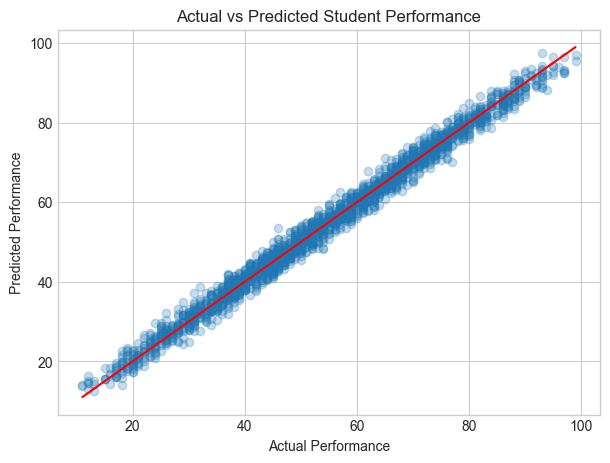

In [10]:
plt.figure(figsize=(7, 5))
plt.scatter(results["Actual Performance"], results["Predicted Performance"], alpha=0.25)
plt.plot([results["Actual Performance"].min(), results["Actual Performance"].max()],
         [results["Actual Performance"].min(), results["Actual Performance"].max()],
         color="red")
plt.title("Actual vs Predicted Student Performance")
plt.xlabel("Actual Performance")
plt.ylabel("Predicted Performance")
plt.show()

## 6. Data Storytelling Presentation

In [11]:
top_factor = correlations.index[0]

print("Capstone story:")
print(f"1. The strongest numeric factor connected to performance is {top_factor}.")
print(f"2. The model predicts performance with an average error of about {mae:.2f} points.")
print(f"3. The R2 score is {r2:.2f}, showing how much variation the model explains.")
print("4. Recommendation: use the model to identify students who may need support, then let teachers decide the action.")

Capstone story:
1. The strongest numeric factor connected to performance is Previous Scores.
2. The model predicts performance with an average error of about 1.61 points.
3. The R2 score is 0.99, showing how much variation the model explains.
4. Recommendation: use the model to identify students who may need support, then let teachers decide the action.


## Final Learner Deliverable

Each group should present:

1. Problem statement
2. Key chart
3. Model result
4. One recommendation
5. One limitation